# AED Placement Optimization

In [1]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point, Polygon
import time
from geopy.geocoders import ArcGIS

## 1. Importing Data

In [6]:
url2 = 'https://raw.githubusercontent.com/JeroenGuillierme/Project-MDA/main/Data/'

interventions_data = pd.read_csv(
    f'{url2}rta_df.csv')
aed_data =pd.read_csv(f'{url2}total_df_with_distances.csv')

# Load Belgium shapefile
belgium_boundary = gpd.read_file(f'{url2}Belgi%C3%AB.json')
# Load Belgium with regions shapefile
belgium_with_provinces_boundary = gpd.read_file(f'{url2}BELGIUM_-_Provinces.geojson')

pd.set_option('display.max_columns', None)

## 2. Functions

In [7]:
# Function to calculate cell size in decimal degrees based on desired grid area and latitude
def calculate_cell_size(grid_area_km2, latitude_degrees):
    '''
    This function calculates the cell size in degrees based on a given grid size in km² and the latitude coordinate.
    :param grid_area_km2: Wanted grid are in km².
    :param latitude_degrees: The latitude coordinate at which the grid size in degrees need to be calculated.
    :return: The degrees of the cell size used to split Belgium up in different grids of given area in km².
    '''
    # Convert latitude to radians for trigonometric functions
    latitude_rad = np.radians(latitude_degrees)

    # Conversion factor from meters to decimal degrees for latitude
    meters_to_degrees = 1 / (111.32 * 1000 * np.cos(latitude_rad))

    # Calculate width of the square grid cell in meters
    width_meters = np.sqrt(grid_area_km2 * 1000000)

    # Calculate cell size in decimal degrees
    cell_size_degrees = width_meters * meters_to_degrees

    return cell_size_degrees

## 3. Data Preparation

Create two different datasets which only contain the intervention and AED locations respectively.

In [9]:
interventions_locations = interventions_data
aed_locations = aed_data[aed_data['AED'] == 1]
print(f'There are currently {len(aed_locations)} AEDs in Belgium')


There are currently 13916 AEDs in Belgium


In [11]:
# Check for missing values
print('Missing values per variable: \n', aed_locations.isnull().sum())
print('Length dataset: ', len(aed_locations))

Missing values per variable: 
 Latitude                     0
Longitude                    0
Intervention                 0
Eventlevel               13916
T3-T0                    13916
EventType                    0
Vector type                  0
AED                          0
Ambulance                    0
Mug                          0
PIT                          0
Province                    11
distance_to_aed              0
distance_to_ambulance    13916
distance_to_mug          13916
distance_to_pit          13916
dtype: int64
Length dataset:  13916


### 3.1 Remove duplicated values from the dataset

In [12]:
print('------------- Before removing duplicates -------------')
# Verify the imputation
len1=len(interventions_data)
print('Total length of interventions dataset: ', len1)

interventions_data_without_dups = interventions_data.drop_duplicates()

print('------------- After removing duplicates -------------')
# Verify the imputation
len2=len(interventions_data_without_dups)
print('Total length of interventions dataset: ', len2)
print('In total: ', len1-len2, ' duplicates removed.')

interventions_data[interventions_data.duplicated(keep=False)==True].head(6) # visual check if the rows are in fact exactly the same

------------- Before removing duplicates -------------
Total length of interventions dataset:  11181
------------- After removing duplicates -------------
Total length of interventions dataset:  11035
In total:  146  duplicates removed.


,Latitude,Longitude,Intervention,Eventlevel,T3-T0,EventType,Vector type,AED,Ambulance,Mug,PIT,Province,distance_to_aed,distance_to_ambulance,distance_to_mug,distance_to_pit,RT_category
2965,50.864708,4.442090,1,1.0,9.933333,P003 - HARTSTILSTAND - DOOD - OVERLEDEN,Ambulance,0,0,0,0,Vlaams Brabant,0.640844,1.916140,1.415817,6.238844,Long (>8 min)
2966,50.864708,4.442090,1,1.0,9.933333,P003 - HARTSTILSTAND - DOOD - OVERLEDEN,Ambulance,0,0,0,0,Vlaams Brabant,0.640844,1.916140,1.415817,6.238844,Long (>8 min)
2990,50.809178,4.931566,1,1.0,5.066667,P003 - HARTSTILSTAND - DOOD - OVERLEDEN,Ambulance,0,0,0,0,Vlaams Brabant,0.303610,1.656617,0.225433,19.403744,Medium (4-8 min)
2991,50.809178,4.931566,1,1.0,5.066667,P003 - HARTSTILSTAND - DOOD - OVERLEDEN,Ambulance,0,0,0,0,Vlaams Brabant,0.303610,1.656617,0.225433,19.403744,Medium (4-8 min)
3005,50.962068,4.624144,1,1.0,38.666667,P003 - HARTSTILSTAND - DOOD - OVERLEDEN,Ambulance,0,0,0,0,Vlaams Brabant,0.809460,0.946307,7.600298,9.920538,Long (>8 min)
3006,50.962068,4.624144,1,1.0,38.666667,P003 - HARTSTILSTAND - DOOD - OVERLEDEN,Ambulance,0,0,0,0,Vlaams Brabant,0.809460,0.946307,7.600298,9.920538,Long (>8 min)


## 4. Heatmap of Incident Desnity

### 4.1 Create Kernel Density Estimate (KDE) plot

Text(101.49999999999999, 0.5, 'Latitude')

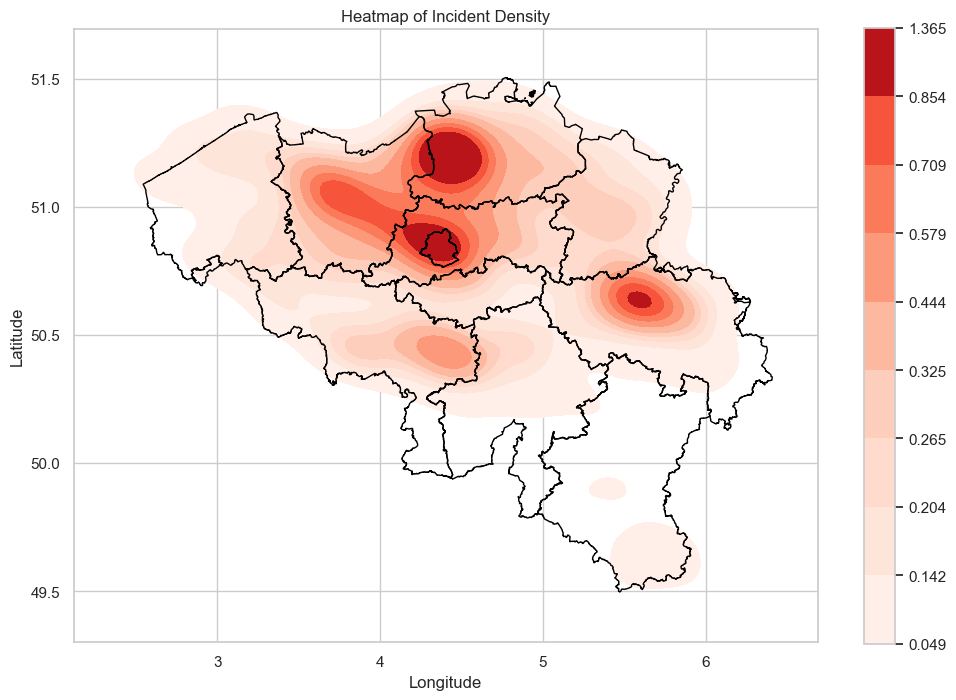

In [85]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.set(style='whitegrid')
kde = sns.kdeplot(data=interventions_data_without_dups, x='Longitude', y='Latitude', cmap='Reds',
                  fill=True, ax=ax, cbar=True)

belgium_boundary.plot(ax=ax, facecolor='none', edgecolor='black')
ax.set_title('Heatmap of Incident Density')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

### 4.2 Create a GeaDataframe from the interventions data

In [18]:
# Create a GeoDataFrame from interventions data
gdf_interventions = gpd.GeoDataFrame(
    interventions_data_without_dups,
    geometry=gpd.points_from_xy(interventions_data_without_dups.Longitude, interventions_data_without_dups.Latitude)
)
print(len(gdf_interventions))

# Filter out invalid geometries
gdf_interventions = gdf_interventions[gdf_interventions['geometry'].is_valid]
print(len(gdf_interventions)) # No invalid geometries found

11035
11035


### 4.3 Adding Incident Density to Dataset

In [22]:
belgium_boundary.total_bounds

array([ 2.55535555, 49.49721527,  6.40833998, 51.50382233])

#### 4.3.1 Define size of the grid area in which Belgium will be divided

In [68]:
# Define size grid area in which we will divide Beligum
grid_area_km2 = 3  # Desired grid area in km²

# Calculate mean latitude from interventions locations
mean_latitude_int = gdf_interventions.geometry.centroid.y.mean()
print(f'The mean latitude of the interventions is: {mean_latitude_int}')

# Calculate mean latitude from Belgium
mean_latitude_bel = belgium_boundary.geometry.centroid.y.mean()
print(f'The mean latitude of Belgium is: {mean_latitude_bel}')

# Calculate cell size in decimal degrees
cell_size_degrees = calculate_cell_size(grid_area_km2, mean_latitude_bel)
print(f'The cell size in degrees is: {cell_size_degrees}')

The mean latitude of the interventions is: 50.85202892563806
The mean latitude of Belgium is: 50.641049377389436
The cell size in degrees is: 0.024534495318782244


#### 4.3.2 Create the grid over the study area, namely Belgium

In [69]:
# Create a grid over the study area: Belgium
xmin, ymin, xmax, ymax = belgium_boundary.total_bounds
cell_size = 0.025  # Adjust the cell size as needed
grid_cells = []
for x0 in np.arange(xmin, xmax + cell_size_degrees, cell_size_degrees):
    for y0 in np.arange(ymin, ymax + cell_size_degrees, cell_size_degrees):
        x1 = x0 - cell_size_degrees
        y1 = y0 + cell_size_degrees
        grid_cells.append(Polygon([(x0, y0), (x1, y0), (x1, y1), (x0, y1)]))

grid = gpd.GeoDataFrame(grid_cells, columns=['geometry'])
print(len(grid))

# Filter out invalid geometries
grid = grid[grid['geometry'].is_valid]
print(len(grid)) # Zero invalid geometries filtered out

13197
13197


#### 4.3.3 Count number of incidents per grid and add to dataset

In [70]:
# Spatial join the grid with the intervention location points
joined_interventions = gpd.sjoin(gdf_interventions, grid, how='left')

# Count incidents in each grid cell
incident_counts = joined_interventions.groupby('index_right').size()

# Map incidents counts to the grid
grid['incident_count'] = 0 # Initialize the incident counts per grid as zero
grid.loc[incident_counts.index, 'incident_count'] = incident_counts.values
# print(grid['incident_count'].sort_values(ascending=True).value_counts())

# Perform a spatial join to add the incident_count to the interventions data
gdf_interventions_with_incident_count = gpd.sjoin(gdf_interventions, grid[['geometry', 'incident_count']], how='left')

# Drop the index right column
gdf_interventions_with_incident_count = gdf_interventions_with_incident_count.drop(columns='index_right')

#### 4.3.4 Visualization of self-counted Incident Density

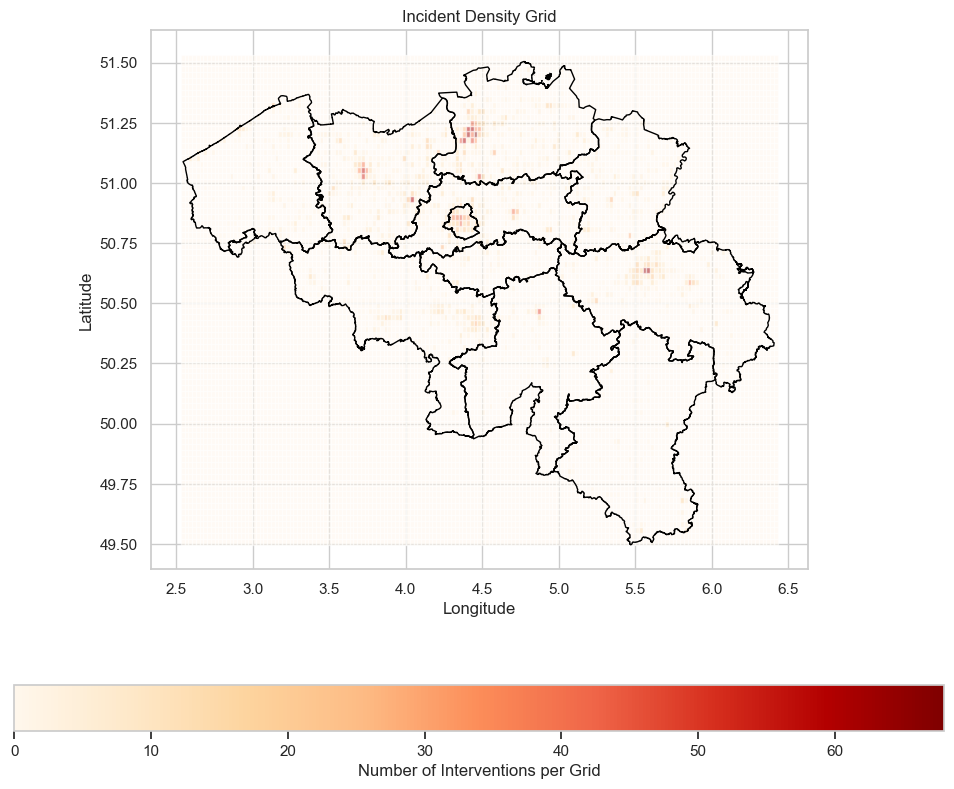

In [86]:
# Plot the incident density
fig, ax = plt.subplots(figsize=(12, 10))
grid.plot(column='incident_count', ax=ax, cmap='OrRd', alpha=0.5, legend=True,
         legend_kwds={"label": "Number of Interventions per Grid", "orientation": "horizontal"})
belgium_boundary.plot(ax=ax, facecolor='none', edgecolor='black')
ax.set_title('Incident Density Grid')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()

## 5. Heatmap of AED Density

### 5.1 Create Kernel Density Estimate (KDE) plot

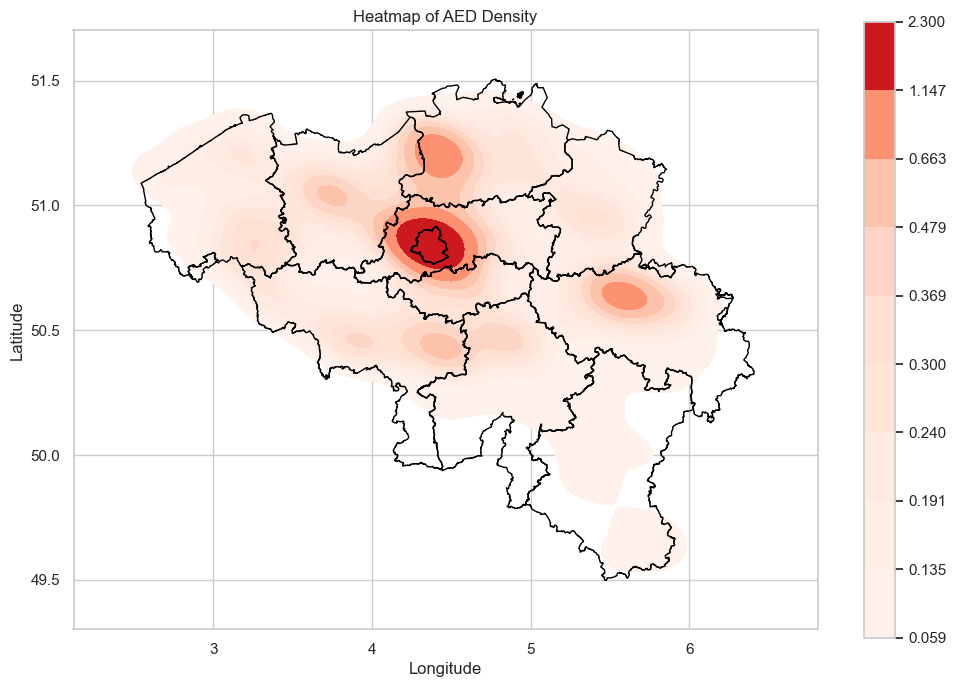

In [87]:
fig, ax = plt.subplots(figsize=(12, 8))

kde = sns.kdeplot(data=aed_locations, x='Longitude', y='Latitude', cmap='Reds',
                  fill=True, ax=ax, cbar=True)

belgium_boundary.plot(ax=ax, facecolor='none', edgecolor='black')
ax.set_title('Heatmap of AED Density')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()

### 5.2 Create a GeoDataframe from AED data

In [74]:
# Convert to GeoDataFrame
gdf_aed_locations = gpd.GeoDataFrame(
    aed_locations,
    geometry=gpd.points_from_xy(aed_locations.Longitude, aed_locations.Latitude)
)
print(len(gdf_aed_locations))

# Filter out invalid geometries
gdf_aed_locations = gdf_aed_locations[gdf_aed_locations['geometry'].is_valid]
print(len(gdf_aed_locations)) # No invalid geometries found

13916
13916


### 5.3 Adding AED Density to Dataset

#### 5.3.1 Count number of AEDs per grid

In [75]:
# Spatial join the grid with the aed locations points
joined_aed = gpd.sjoin(gdf_aed_locations, grid, how='left')

# Count incidents in each grid cell
aed_counts = joined_aed.groupby('index_right').size()

# Map incidents counts to the grid
grid['aed_count'] = 0
grid.loc[aed_counts.index, 'aed_count'] = aed_counts.values

#### 5.3.2 Visualization of self-counted AED Density

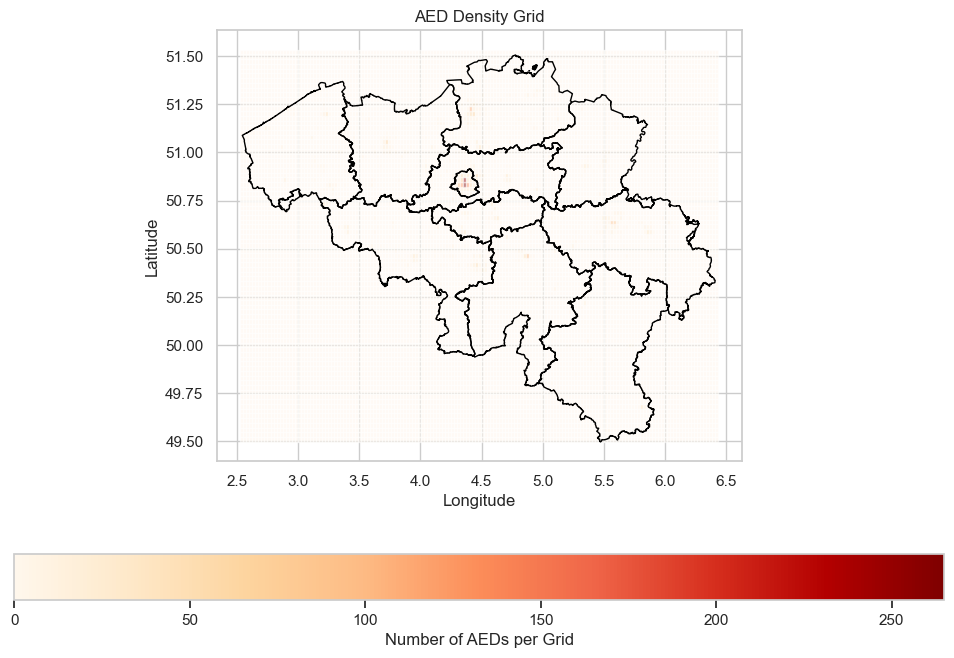

In [88]:
# Plot the AED density
fig, ax = plt.subplots(figsize=(12, 8))
grid.plot(column='aed_count', ax=ax, cmap='OrRd', alpha=0.5, legend=True,
         legend_kwds={"label": "Number of AEDs per Grid", "orientation": "horizontal"})
belgium_boundary.plot(ax=ax, facecolor='none', edgecolor='black')
ax.set_title('AED Density Grid')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()

#### 5.3.3 Combine incident and AED count to interventions data

In [77]:
# Perform a spatial join to add the incident_count to the interventions data
gdf_interventions_with_both_count = gpd.sjoin(gdf_interventions_with_incident_count, grid[['geometry', 'aed_count']],
                                              how='left')
gdf_interventions_with_both_count.drop(columns='index_right').head(5)

,Latitude,Longitude,Intervention,Eventlevel,T3-T0,EventType,Vector type,AED,Ambulance,Mug,PIT,Province,distance_to_aed,distance_to_ambulance,distance_to_mug,distance_to_pit,RT_category,geometry,incident_count,aed_count
0,51.24848,4.43869,1,1.0,4.238700,P003 - Cardiac arrest,Ambulance,0,0,0,0,Antwerpen,0.335321,1.454942,1.259929,2.493499,Medium (4-8 min),POINT (4.43869 51.24848),41,32
1,51.28273,4.42134,1,1.0,36.619500,P003 - Cardiac arrest,Ambulance,0,0,0,0,Antwerpen,0.083377,3.262920,3.434839,5.712662,Long (>8 min),POINT (4.42134 51.28273),13,10
2,51.17895,4.39024,1,2.0,10.955033,P003 - Cardiac arrest,Ambulance,0,0,0,0,Antwerpen,0.178210,2.980275,1.578813,6.097983,Long (>8 min),POINT (4.39024 51.17895),60,17
3,51.20520,4.76586,1,0.0,9.628933,P003 - Cardiac arrest,Ambulance,0,0,0,0,Antwerpen,0.489422,5.373831,5.464297,16.218601,Long (>8 min),POINT (4.76586 51.2052),2,5
4,51.06293,4.45693,1,1.0,8.356450,P003 - Cardiac arrest,Ambulance,0,0,0,0,Antwerpen,0.166553,2.220918,3.595612,7.666810,Long (>8 min),POINT (4.45693 51.06293),6,29


## 6. Response Time threshhold

<Axes: title={'center': 'PIT Response Times by Location'}, xlabel='Longitude', ylabel='Latitude'>

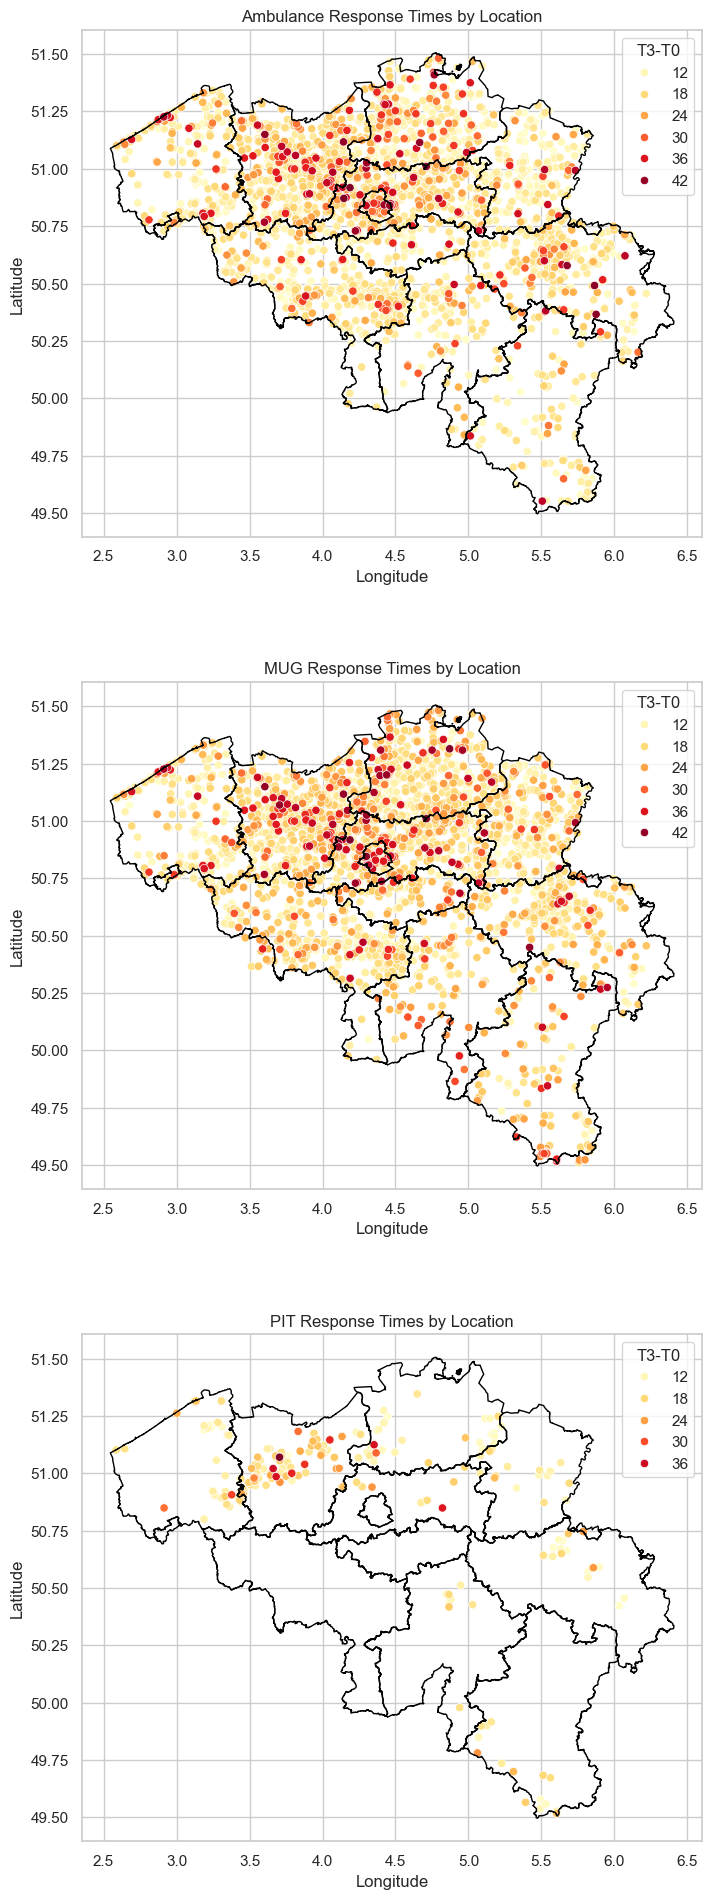

In [96]:
# Only check Response times longer then 10 minutes
# (According to literature waiting longer ten 10 minutes could be life-threatening)
ResponseTimeFilterd = gdf_interventions_with_both_count[gdf_interventions_with_both_count['T3-T0'] > 10]
ResponseTimeFilterd_sorted = ResponseTimeFilterd.sort_values(by='T3-T0', ascending=True)


ResponseTimeFilterd_sorted_amb = ResponseTimeFilterd_sorted[ResponseTimeFilterd_sorted['Vector type'] == 'Ambulance']
ResponseTimeFilterd_sorted_mug = ResponseTimeFilterd_sorted[ResponseTimeFilterd_sorted['Vector type'] == 'MUG']
ResponseTimeFilterd_sorted_pit = ResponseTimeFilterd_sorted[ResponseTimeFilterd_sorted['Vector type'] == 'PIT']

fig, ax = plt.subplots(3, 1, figsize=(8,24))

sns.scatterplot(
    data=ResponseTimeFilterd_sorted_amb,
    x='Longitude', y='Latitude',
    hue='T3-T0', palette='YlOrRd',
    legend='brief', ax=ax[0]).set(
    title='Ambulance Response Times by Location', xlabel= 'Longitude', ylabel='Latitude')
sns.scatterplot(
    data=ResponseTimeFilterd_sorted_mug,
    x='Longitude', y='Latitude',
    hue='T3-T0', palette='YlOrRd',
    legend='brief', ax=ax[1]).set(
    title='MUG Response Times by Location', xlabel= 'Longitude', ylabel='Latitude')
sns.scatterplot(
    data=ResponseTimeFilterd_sorted_pit,
    x='Longitude', y='Latitude',
    hue='T3-T0', palette='YlOrRd',
    legend='brief', ax=ax[2]).set(
    title='PIT Response Times by Location', xlabel= 'Longitude', ylabel='Latitude')
belgium_with_provinces_boundary.plot(ax=ax[0], facecolor='none', edgecolor='black')
belgium_with_provinces_boundary.plot(ax=ax[1], facecolor='none', edgecolor='black')
belgium_with_provinces_boundary.plot(ax=ax[2], facecolor='none', edgecolor='black')

## 7. Identifying Hotspots or High-Risk Areas

Note: These thresholds are chosen arbitrary.

We defined a high risk area as an area of 3km² in which:
* There are more than 5 cardiac arrests
* The response times of these incidents are larger than 10 minutes
* There are less then 5 AEDs.

Literature says (https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7892213/): 

'We found that a short Emergency Medical Service (EMS) response time was associated with a high rate of survival 
to hospital discharge after Out-of-Hospital Cardiac Arrest (OHCA). 
The optimal response time threshold for survival to hospital discharge was 6.2min. 
In the case of OHCA in public areas or with bystander CPR, the threshold was prolonged to 7.2min and 6.3min, 
respectively; and in the absence of a witness, the threshold was shortened to 4.2min.'

About the incident density it says:

'Incident density, or the frequency of events in a specific area, can impact ambulance response times and survival 
outcomes for out-of-hospital cardiac arrest (OHCA) patients.
High incident density areas may lead to longer response times due to increased demand on emergency medical services(EMS)
resources.'

In [97]:
# Define high-risk based on response time, incident frequency and aed density
response_time_threshold = 10  # minutes
incident_density_threshold = 5  # more than five previous interventions on that location area
aed_density_threshold = 5  # less than 5 aeds in the 3 km³ grid for that location


# Identify high-risk areas
high_risk_areas = gdf_interventions_with_both_count[
    (gdf_interventions_with_both_count['T3-T0'] > response_time_threshold) &
    (gdf_interventions_with_both_count['incident_count'] > incident_density_threshold) &
    (gdf_interventions_with_both_count['aed_count'] < aed_density_threshold)
    ]

print(
    'Number of high risk areas in Belgium according to chosen thresholds: ',
    len(high_risk_areas[['Latitude', 'Longitude']].drop_duplicates()))


Number of high risk areas in Belgium according to chosen thresholds:  730


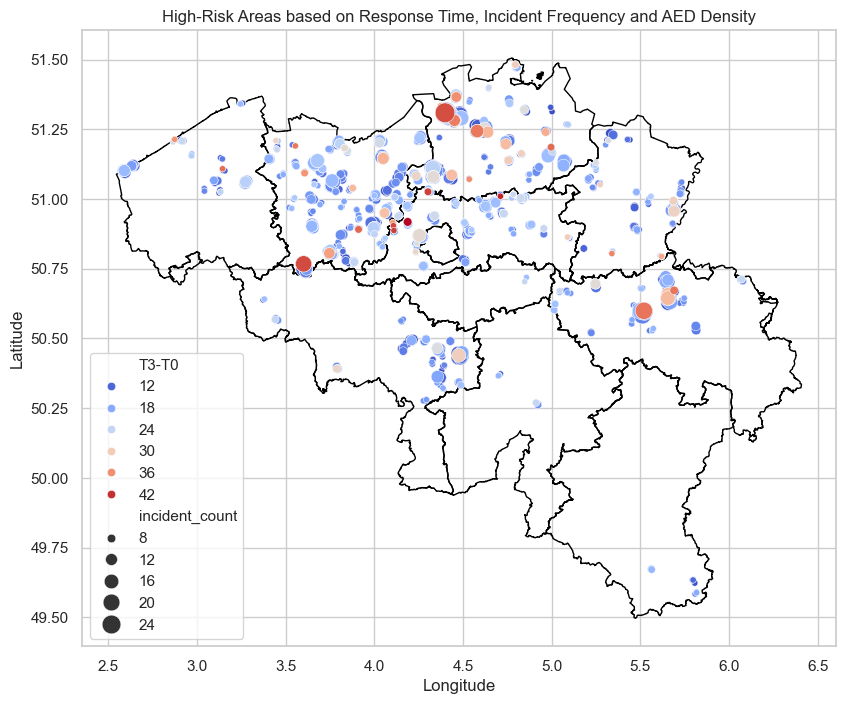

In [99]:
# Visualise high-risk areas
fig, ax = plt.subplots(figsize=(12, 8))
belgium_with_provinces_boundary.plot(ax=ax, facecolor='none', edgecolor='black')
scatter = sns.scatterplot(data=high_risk_areas.sort_values(by='T3-T0', ascending=True),
                          x='Longitude', y='Latitude',
                          size='incident_count', hue='T3-T0', palette='coolwarm',
                          sizes=(20, 200), legend='auto', ax=ax)
ax.set_title('High-Risk Areas based on Response Time, Incident Frequency and AED Density')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()


## 8. Clustering High-Risk Areas Using DBSCAN as spatial clustering algorithm

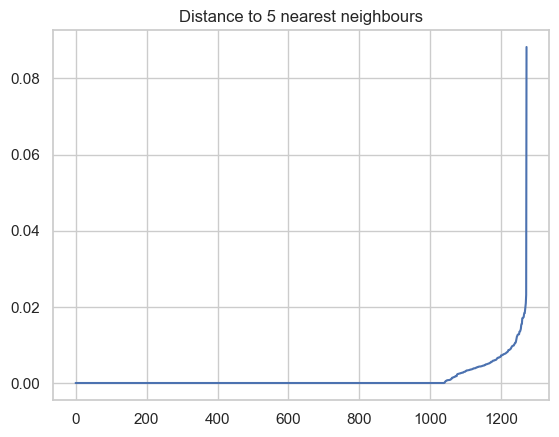

In [101]:
# Identify high-risk areas to identify hotspots or highly concentrated high risk areas

# Calculate the average distance between each point in the data set and its 20 nearest neighbors
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(high_risk_areas[['Latitude', 'Longitude']])
distances, indices = neighbors_fit.kneighbors(high_risk_areas[['Latitude', 'Longitude']])

# Sort distance values by ascending value and plot
distances = np.sort(distances, axis=0)
distances = distances[:, 1]
plt.title('Distance to 5 nearest neighbours')
plt.plot(distances)

### 8.1 Initialize DBSCAN clustering

This algorithm will consider a point as a core point if at least 5 points are within a distance of 3km

In [103]:
# Choose eps based on the k-distance graph
eps = cell_size_degrees  # See earlier for determining grid size: eps = 0.02463... this is approximately 3km

# Choose min_samples based on the data density
# A point is considered a core point if at least 5 points are within a distance of 3km
min_samples = 5

# Initialize DBSCAN
dbscan = DBSCAN(eps=eps, min_samples=min_samples)

# Perform clustering
high_risk_areas.loc[:, 'cluster'] = dbscan.fit_predict(high_risk_areas[['Latitude', 'Longitude']])

# Drop noise points (cluster == -1)
# Filter out noise points (cluster == -1)
high_risk_areas_filtered = high_risk_areas[high_risk_areas['cluster'] != -1]

### 8.1 Determine new AED locations (cluster centers)

In [111]:
cluster_centers = high_risk_areas_filtered.groupby('cluster')[['Latitude', 'Longitude']].mean()
cluster_sizes = high_risk_areas_filtered['cluster'].value_counts()
labels = dbscan.labels_

print('New AED Locations: \n')

cluster_centers.head(5)

New AED Locations: 



,Latitude,Longitude
cluster,,
0,51.267598,5.087972
1,51.249256,4.581321
2,51.150807,4.621117
3,51.281536,4.452859
4,51.084362,4.871898


In [114]:
# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

# Evaluation metrics

sc = silhouette_score(high_risk_areas[['Latitude', 'Longitude']], labels)
print("Silhouette Coefficient:%0.2f" % sc)

Estimated number of clusters: 134
Estimated number of noise points: 96
Silhouette Coefficient:0.67


### 8.2 Visualize new clusters and their size

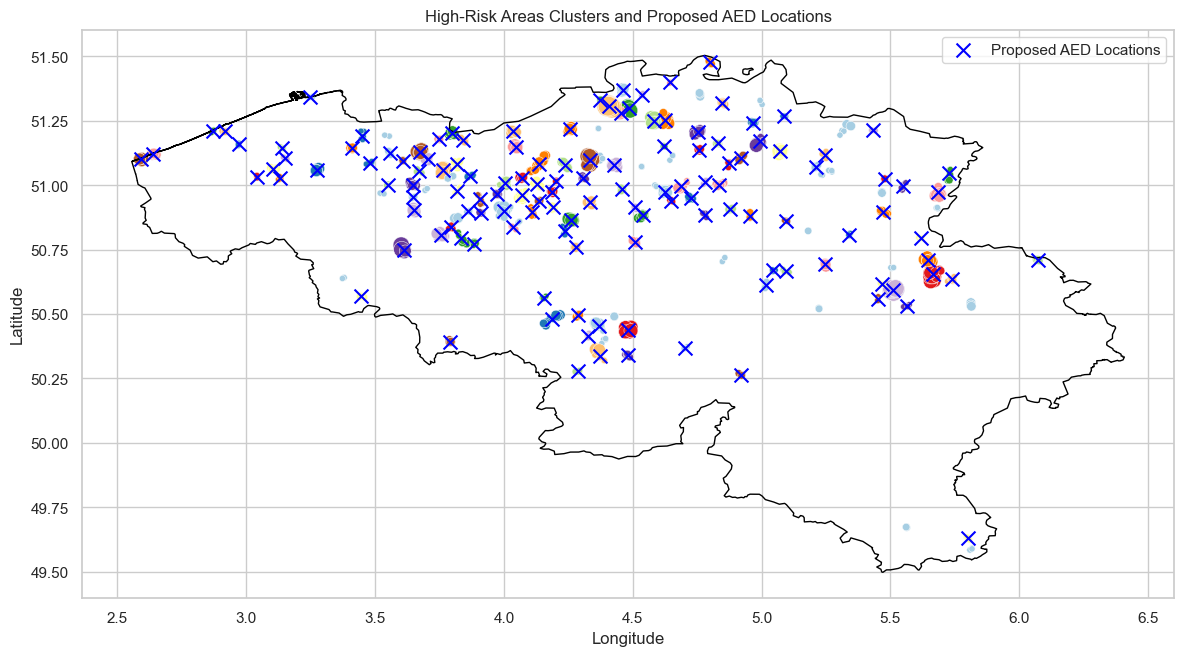

In [115]:
# Plot clusters
fig, ax = plt.subplots(figsize=(12, 8))
custom_palette = sns.color_palette("Paired", len(cluster_sizes) + 1)
# Plot the high-risk areas and color by cluster
scatter = sns.scatterplot(
    data=high_risk_areas,
    x='Longitude', y='Latitude',
    hue='cluster', palette=custom_palette,
    size='incident_count',
    sizes=(20, 200), legend=False, ax=ax)
# Overlay the Belgium boundary
belgium_boundary.plot(ax=ax, facecolor='none', edgecolor='black')

# Overlay the proposed AED locations
new_aed_gdf = gpd.GeoDataFrame(cluster_centers,
                               geometry=gpd.points_from_xy(cluster_centers['Longitude'], cluster_centers['Latitude']))
new_aed_gdf.plot(ax=ax, marker='x', color='blue', markersize=100, label='Proposed AED Locations')

ax.set_title('High-Risk Areas Clusters and Proposed AED Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

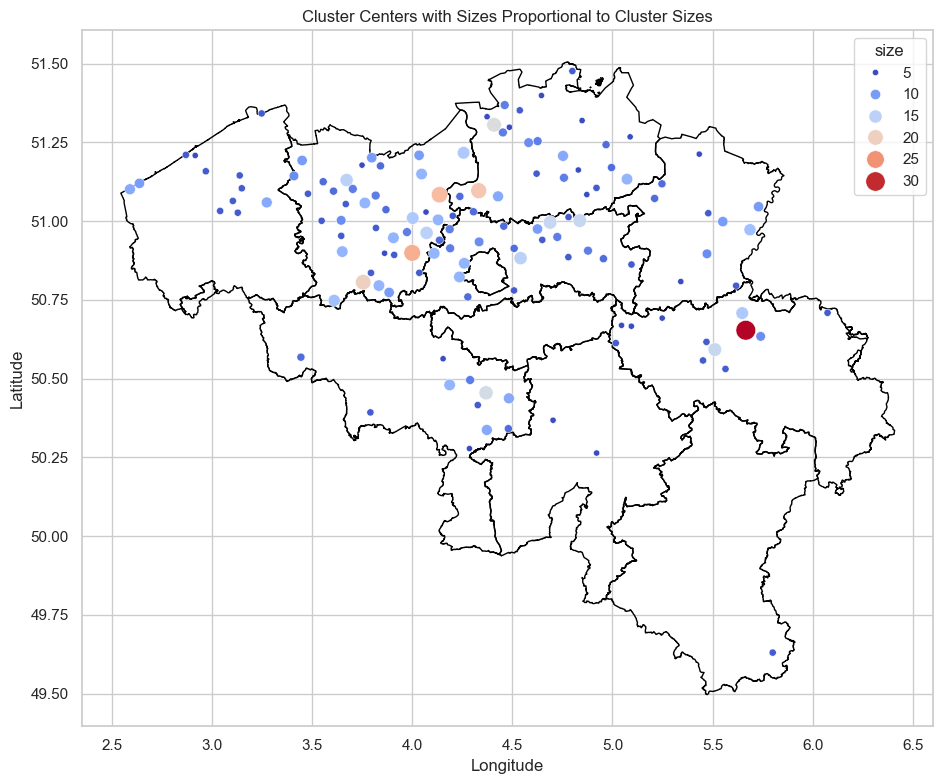

In [116]:
# New plot for cluster sizes
fig, ax = plt.subplots(figsize=(12, 8))

# Prepare cluster centers with sizes
cluster_centers['size'] = cluster_sizes

# Plot only cluster centers with sizes and colors depending on cluster size to determine most 'problematic' clusters
belgium_with_provinces_boundary.plot(ax=ax, facecolor='none', edgecolor='black')
scatter = sns.scatterplot(data=cluster_centers,
                          x='Longitude', y='Latitude', size='size', sizes=(20, 200),
                          hue='size', palette='coolwarm', legend='brief')
ax.set_title('Cluster Centers with Sizes Proportional to Cluster Sizes')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

## 9. Save new AED locations to a new dataset

In [ ]:
# Save cluster centers to new csv file
#new_aed_gdf[['Latitude', 'Longitude']].to_csv(
#    'Data/new_aed_locations.csv', index=True)